# Tagger Baseado em RNN

In [1]:
# 1. Clona o projeto para o ambiente temporário do Colab
!git clone https://github.com/lucasaamorim/NLP

fatal: destination path 'NLP' already exists and is not an empty directory.


In [2]:
# 2. Entra na pasta do projeto
%cd NLP

/content/NLP


In [3]:
# 3. Instala o arquivo de dependências (caso o notebook use algo além do TensorFlow padrão)
!uv pip install keras scikit-learn nltk regex

Using Python 3.12.13 environment at: /usr
Checked 4 packages in 189ms


In [52]:
import numpy as np
import keras
from keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from src.utils.data_loader import load_tagging_data
from src.utils.preprocessing import tokenize_sentences, vectorize_tags

In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [6]:
%cd /content/drive/MyDrive/pos_tagging_data/data

/content/drive/MyDrive/pos_tagging_data/data


In [7]:
# ln -s /caminho/real/no/drive /content/nome_que_o_codigo_espera
!ln -s "/content/drive/MyDrive/pos_tagging_data/data" "/content/NLP/data"

ln: failed to create symbolic link '/content/NLP/data/data': File exists


###Carregando os dados de POS Tagging

In [53]:
data = load_tagging_data()
print("Dados do POS Tagging carregados")

Dados do POS Tagging carregados


###Separando os splits originais

In [9]:
train_sentences = data["train"]["sentences"]
train_tags = data["train"]["tags"]

val_sentences = data["val"]["sentences"]
val_tags = data["val"]["tags"]

test_sentences = data["test"]["sentences"]
test_tags = data["test"]["tags"]

print(f"Sentenças de Treino: {len(train_sentences)} | Validação: {len(val_sentences)} | Teste: {len(test_sentences)}")

Sentenças de Treino: 38219 | Validação: 5527 | Teste: 5462


###Processando o Vocabulário de Palavras

In [10]:
vocab_size = 15000  # Limite máximo de palavras únicas
vectorizer, max_len = tokenize_sentences(train_sentences, vocab_size)

X_train = vectorizer([" ".join(s) for s in train_sentences]).numpy()
X_val = vectorizer([" ".join(s) for s in val_sentences]).numpy()
X_test = vectorizer([" ".join(s) for s in test_sentences]).numpy()

###Processando o Vocabulário de Tags

In [12]:
tag_lookup, Y_train = vectorize_tags(train_tags, max_len)

num_tags = tag_lookup.vocabulary_size()

Y_val_list = []
for sentence_tags in val_tags:
    tag_ids = tag_lookup(sentence_tags).numpy()
    pad_length = max_len - len(tag_ids)
    if pad_length > 0:
        padded_tags = np.pad(tag_ids, (0, pad_length), constant_values=0) # 0 é o ID do <PAD>
    else:
        padded_tags = tag_ids[:max_len]
    Y_val_list.append(padded_tags)
Y_val = np.array(Y_val_list)

Y_test_list = []
for sentence_tags in test_tags:
    tag_ids = tag_lookup(sentence_tags).numpy()
    pad_length = max_len - len(tag_ids)
    if pad_length > 0:
        padded_tags = np.pad(tag_ids, (0, pad_length), constant_values=0)
    else:
        padded_tags = tag_ids[:max_len]
    Y_test_list.append(padded_tags)
Y_test = np.array(Y_test_list)

print(f"Formato final de X_train: {X_train.shape}")
print(f"Formato final de Y_train: {Y_train.shape}")
print(f"Formato final de X_test: {X_test.shape}")
print(f"Formato final de Y_test: {Y_test.shape}")
print(f"Número total de tags (classes): {num_tags}")

Formato final de X_train: (38219, 249)
Formato final de Y_train: (38219, 249)
Formato final de X_test: (5462, 249)
Formato final de Y_test: (5462, 249)
Número total de tags (classes): 71


In [13]:
# Hiperparâmetros
embedding_dim = 128
rnn_units = 128
BATCH_SIZE = 32
EPOCHS = 5

inputs = keras.Input(shape=(max_len,), dtype="int32")

rnn = layers.Embedding(
    input_dim=vectorizer.vocabulary_size(),
    output_dim=embedding_dim,
    mask_zero=True
)(inputs)

###Construindo o modelo RNN unidirecional

In [14]:
rnn_unidirecional = layers.SimpleRNN(rnn_units, return_sequences=True)(rnn)

outputs = layers.Dense(num_tags, activation="softmax")(rnn_unidirecional)

rnn_unidirecional_model = keras.Model(inputs, outputs)

rnn_unidirecional_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

rnn_unidirecional_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 249)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 249, 128)  │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 249)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 249, 128)  │     32,896 │ embedding[0][0],  │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 249, 71)   │      9,159 │ simple_rnn[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 298,055 (1.14 MB)

 Trainable params: 298,055 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

###Construindo o modelo LSTM unidirecional


In [15]:
lstm_unidirecional = layers.LSTM(rnn_units, return_sequences=True)(rnn)

outputs = layers.Dense(num_tags, activation="softmax")(lstm_unidirecional)

lstm_unidirecional_model = keras.Model(inputs, outputs)

lstm_unidirecional_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_unidirecional_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 249)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 249, 128)  │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 249)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 249, 128)  │    131,584 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 249, 71)   │      9,159 │ lstm[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 396,743 (1.51 MB)

 Trainable params: 396,743 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

###Construindo o modelo RNN bidirecional

In [16]:
rnn_bidirecional = layers.Bidirectional(layers.SimpleRNN(rnn_units, return_sequences=True))(rnn)

outputs = layers.Dense(num_tags, activation="softmax")(rnn_bidirecional)

rnn_bidirecional_model = keras.Model(inputs, outputs)

rnn_bidirecional_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

rnn_bidirecional_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 249)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 249, 128)  │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 249)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 249, 256)  │     65,792 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 249, 71)   │     18,247 │ bidirectional[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 340,039 (1.30 MB)

 Trainable params: 340,039 (1.30 MB)

 Non-trainable params: 0 (0.00 B)

###Construindo o modelo LSTM Bidirecional

In [17]:
# RNN Bidirecional para capturar contexto tanto da esquerda-para-direita quanto da direita-para-esquerda
lstm_bidirecional = layers.Bidirectional(layers.LSTM(rnn_units, return_sequences=True))(rnn)

# Camada densa distribuída no tempo (computa uma distribuição de probabilidade por palavra)
outputs = layers.Dense(num_tags, activation="softmax")(lstm_bidirecional)

lstm_bidirecional_model = keras.Model(inputs, outputs)

# Usamos SparseCategoricalCrossentropy porque nosso Y contém IDs inteiros (não one-hot vectors)
lstm_bidirecional_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_bidirecional_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 249)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 249, 128)  │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 249)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 249, 256)  │    263,168 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 249, 71)   │     18,247 │ bidirectional_1[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 537,415 (2.05 MB)

 Trainable params: 537,415 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

### Treinamento da RNN Unidirecional

In [18]:
history = rnn_unidirecional_model.fit(
    X_train,
    Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val)
)

Epoch 1/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - accuracy: 0.8132 - loss: 0.6523 - val_accuracy: 0.8654 - val_loss: 0.4021
Epoch 2/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 27s 23ms/step - accuracy: 0.8744 - loss: 0.3707 - val_accuracy: 0.8736 - val_loss: 0.3770
Epoch 3/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step - accuracy: 0.8796 - loss: 0.3519 - val_accuracy: 0.8754 - val_loss: 0.3700
Epoch 4/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.8836 - loss: 0.3395 - val_accuracy: 0.8748 - val_loss: 0.3728
Epoch 5/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.8865 - loss: 0.3308 - val_accuracy: 0.8772 - val_loss: 0.3671


### Treinamento da LSTM Unidirecional

In [19]:
history = lstm_unidirecional_model.fit(
    X_train,
    Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val)
)

Epoch 1/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8316 - loss: 0.6077 - val_accuracy: 0.8709 - val_loss: 0.3879
Epoch 2/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8784 - loss: 0.3580 - val_accuracy: 0.8776 - val_loss: 0.3658
Epoch 3/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8837 - loss: 0.3398 - val_accuracy: 0.8785 - val_loss: 0.3600
Epoch 4/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8874 - loss: 0.3282 - val_accuracy: 0.8803 - val_loss: 0.3588
Epoch 5/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8901 - loss: 0.3194 - val_accuracy: 0.8808 - val_loss: 0.3524


### Treinamento da RNN Bidirecional

In [20]:
history = rnn_bidirecional_model.fit(
    X_train,
    Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val)
)

Epoch 1/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 59s 46ms/step - accuracy: 0.8844 - loss: 0.3797 - val_accuracy: 0.9012 - val_loss: 0.3023
Epoch 2/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 51s 42ms/step - accuracy: 0.9106 - loss: 0.2645 - val_accuracy: 0.9052 - val_loss: 0.2857
Epoch 3/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 50s 42ms/step - accuracy: 0.9158 - loss: 0.2481 - val_accuracy: 0.9061 - val_loss: 0.2785
Epoch 4/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 51s 42ms/step - accuracy: 0.9191 - loss: 0.2367 - val_accuracy: 0.9077 - val_loss: 0.2745
Epoch 5/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 51s 42ms/step - accuracy: 0.9220 - loss: 0.2272 - val_accuracy: 0.9077 - val_loss: 0.2742


### Treinamento da LSTM Bidirecional

In [21]:
history = lstm_bidirecional_model.fit(
    X_train,
    Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val)
)

Epoch 1/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.8808 - loss: 0.4046 - val_accuracy: 0.9051 - val_loss: 0.2849
Epoch 2/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9156 - loss: 0.2495 - val_accuracy: 0.9093 - val_loss: 0.2672
Epoch 3/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9207 - loss: 0.2324 - val_accuracy: 0.9111 - val_loss: 0.2635
Epoch 4/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9246 - loss: 0.2201 - val_accuracy: 0.9128 - val_loss: 0.2604
Epoch 5/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9279 - loss: 0.2101 - val_accuracy: 0.9127 - val_loss: 0.2601


###Função de Avaliação dos modelos

In [49]:
def model_evaluation(model, X_test, Y_test, tag_lookup, model_name):
    # 1. Predict probabilities for each class per word
    predictions_prob = model.predict(X_test)

    # 2. Get the index of the class with the highest probability
    predicted_classes = np.argmax(predictions_prob, axis=-1)

    y_true_filtered = []
    y_pred_filtered = []

    # 3. Filter data by removing ID 0 (<PAD>)
    for i in range(len(Y_test)):
        for j in range(len(Y_test[i])):
            if Y_test[i][j] != 0:  # 0 is the <PAD> ID generated by StringLookup
                y_true_filtered.append(Y_test[i][j])
                y_pred_filtered.append(predicted_classes[i][j])

    # 4. Get the actual vocabulary from your tag_lookup
    full_vocabulary = tag_lookup.get_vocabulary()

    # Find which unique IDs actually remain in y_true
    present_ids = sorted(list(set(y_true_filtered)))

    # --- CORREÇÃO DO JJ E DA ORDEM ALFABÉTICA ---
    # Criamos pares de (Nome único com ID, ID original) para mapear sem duplicar no gráfico
    tag_pairs = []
    for idx in present_ids:
        tag_name = full_vocabulary[int(idx)]
        # Adiciona o ID ao nome (Resolve o problema do JJ duplicado)
        unique_name = f"{tag_name} ({idx})"
        tag_pairs.append((unique_name, idx))

    # Ordena a lista de tuplas em ordem alfabética pelo nome da tag
    tag_pairs_sorted = sorted(tag_pairs, key=lambda x: x[0])

    # Separamos de volta os nomes ordenados alfabeticamente e a ordem dos IDs correspondentes
    alphabetical_names = [pair[0] for pair in tag_pairs_sorted]
    alphabetical_ids = [pair[1] for pair in tag_pairs_sorted]

    print("\n" + "="*50)
    print("Classification Report Without Padding")
    print("="*50)
    # No relatório de texto, usamos a ordem alfabética mapeando os nomes limpos (sem o sufixo do ID para o relatório ficar bonito)
    clean_alphabetical_names = [full_vocabulary[int(idx)] for idx in alphabetical_ids]
    print(classification_report(y_true_filtered, y_pred_filtered, labels=alphabetical_ids, target_names=clean_alphabetical_names, zero_division=0))

    # 5. Confusion Matrix alinhada com a nova ordem alfabética
    cm = confusion_matrix(y_true_filtered, y_pred_filtered, labels=alphabetical_ids)

    with np.errstate(all='ignore'):
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_normalized = np.nan_to_num(cm_normalized)

    # Aumentamos um pouco o tamanho para acomodar os espaçamentos retos das palavras
    plt.figure(figsize=(18, 14))

    # Renderiza a matriz normalizada usando os nomes em ordem alfabética e com IDs únicos
    ax = sns.heatmap(cm_normalized, annot=False, cmap="Blues", vmin=0.0, vmax=1.0,
                xticklabels=alphabetical_names, yticklabels=alphabetical_names)

    # --- CORREÇÃO DO ESPAÇAMENTO SEM ROTACIONAR ---
    ax.tick_params(axis='x', rotation=90, labelsize=10, pad=12)
    ax.tick_params(axis='y', rotation=0, labelsize=10, pad=12)

    plt.title(f"Matriz de Confusão (Normalizada) - {model_name}", fontsize=14, pad=25)
    plt.xlabel("Predito", fontsize=12, labelpad=20) # Aumentado o recuo do título do eixo X
    plt.ylabel("Real", fontsize=12, labelpad=20)    # Aumentado o recuo do título do eixo Y

    plt.tight_layout()
    plt.show()

### Avaliação da RNN Unidirecional

171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

Classification Report Without Padding
              precision    recall  f1-score   support

           #       1.00      1.00      1.00        15
           $       1.00      0.99      1.00       943
         ''
       1.00      0.98      0.99       312
          ''       0.99      1.00      0.99       733
          ,
       0.00      0.00      0.00         1
           ,       1.00      1.00      1.00      6875
       -LRB-       1.00      1.00      1.00       186
      -RRB-
       0.00      0.00      0.00        13
       -RRB-       0.93      1.00      0.96       174
          .
       0.93      1.00      0.96      5003
           .       0.50      0.00      0.01       378
          :
       0.37      0.21      0.26        87
           :       0.90      0.95      0.93       665
          CC       0.99      0.99      0.99      3250
         CD
       0.00      0.00      0.00         2
          CD       0.67      0.90      0.77      4821
 

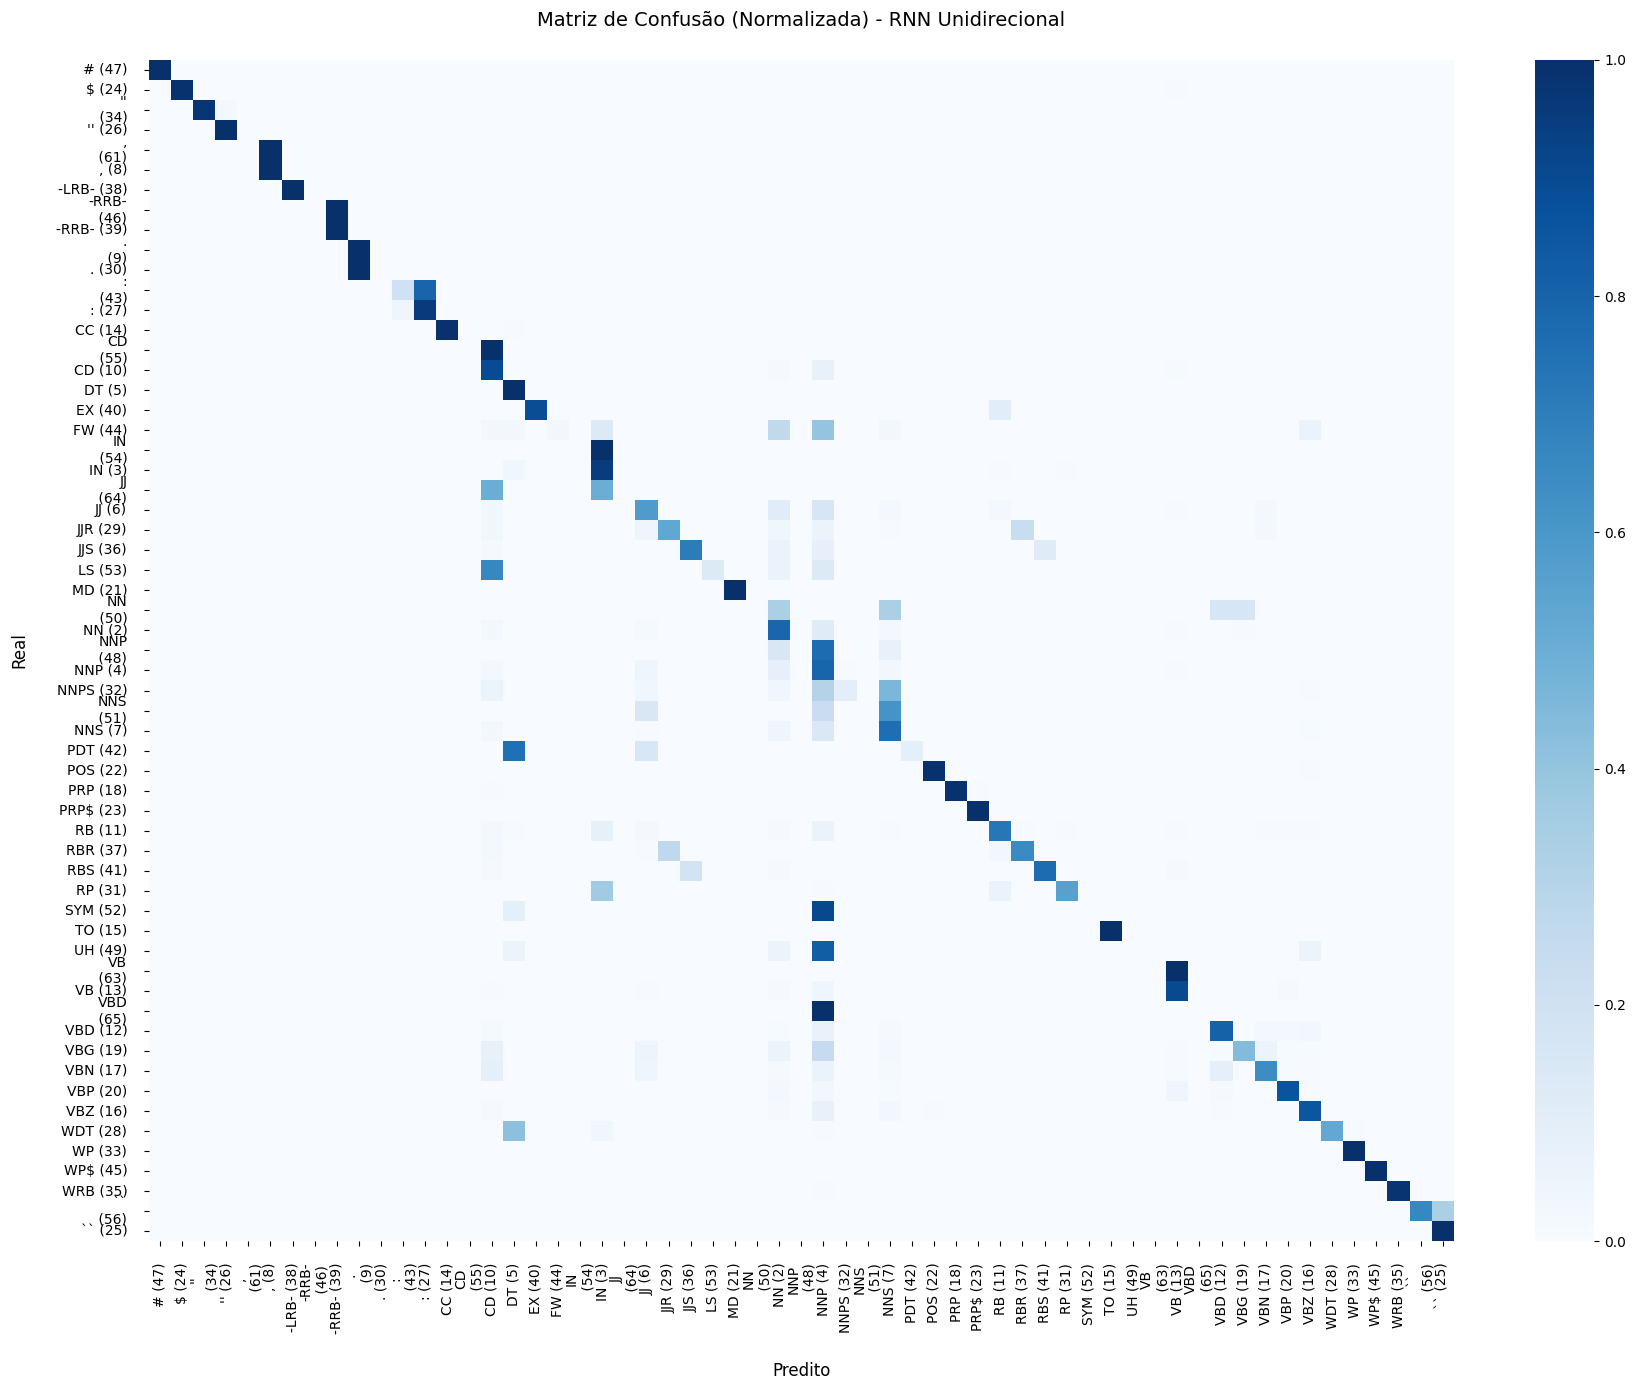

In [54]:
model_evaluation(rnn_unidirecional_model, X_test, Y_test, tag_lookup, "RNN Unidirecional")

### Avaliação da LSTM Unidirecional

171/171 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

Classification Report Without Padding
              precision    recall  f1-score   support

          NN       0.77      0.87      0.82     17828
          IN       0.95      0.98      0.96     13487
         NNP       0.78      0.77      0.77     13164
          DT       0.99      0.99      0.99     11183
          JJ       0.77      0.62      0.69      8213
         NNS       0.74      0.82      0.78      8048
           ,       1.00      1.00      1.00      6875
          .
       0.95      0.99      0.97      5003
          CD       0.93      0.89      0.91      4821
          RB       0.87      0.74      0.80      4405
         VBD       0.87      0.86      0.86      4560
          VB       0.90      0.93      0.91      3572
          CC       0.99      1.00      0.99      3250
          TO       1.00      1.00      1.00      2913
         VBZ       0.89      0.87      0.88      2639
         VBN       0.77      0.75      0.76      2707
 

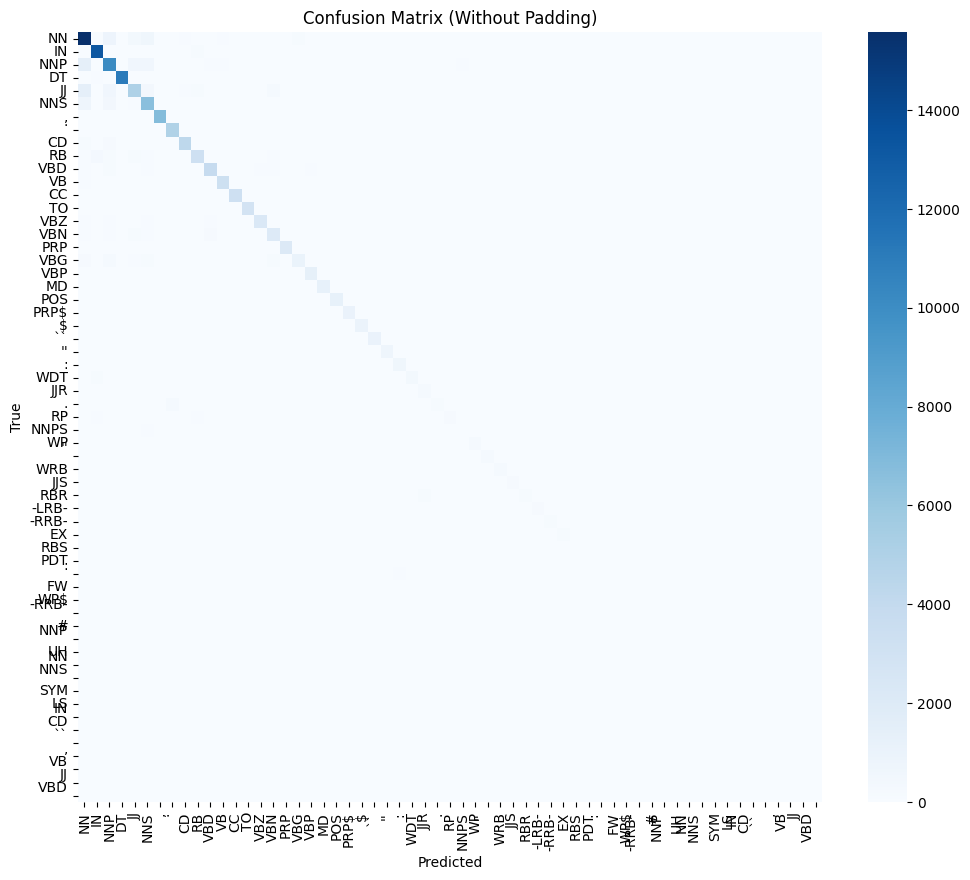

In [24]:
model_evaluation(lstm_unidirecional_model, X_test, Y_test, tag_lookup, "LSTM Unidirecional")

### Avaliação da RNN Bidirecional

171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

Classification Report Without Padding
              precision    recall  f1-score   support

          NN       0.83      0.79      0.81     17828
          IN       0.95      0.95      0.95     13487
         NNP       0.60      0.79      0.68     13164
          DT       0.93      1.00      0.96     11183
          JJ       0.78      0.58      0.67      8213
         NNS       0.82      0.76      0.79      8048
           ,       1.00      1.00      1.00      6875
          .
       0.93      1.00      0.96      5003
          CD       0.67      0.90      0.77      4821
          RB       0.89      0.73      0.80      4405
         VBD       0.90      0.81      0.85      4560
          VB       0.89      0.90      0.90      3572
          CC       0.99      0.99      0.99      3250
          TO       1.00      1.00      1.00      2913
         VBZ       0.86      0.85      0.86      2639
         VBN       0.78      0.64      0.70      2707
 

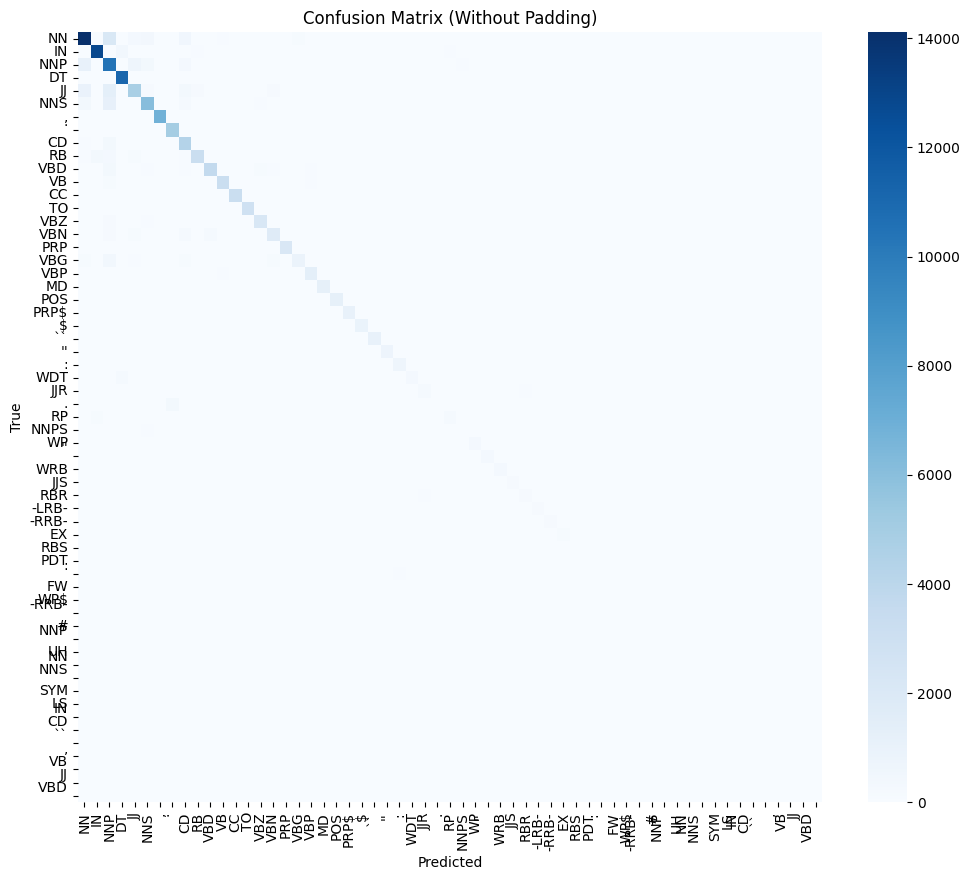

In [25]:
model_evaluation(rnn_unidirecional_model, X_test, Y_test, tag_lookup, "RNN Bidirecional")

### Avaliação da LSTM Bidirecional

171/171 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

Classification Report Without Padding
              precision    recall  f1-score   support

          NN       0.86      0.89      0.88     17828
          IN       0.98      0.98      0.98     13487
         NNP       0.87      0.85      0.86     13164
          DT       0.99      0.99      0.99     11183
          JJ       0.78      0.81      0.80      8213
         NNS       0.85      0.87      0.86      8048
           ,       1.00      1.00      1.00      6875
          .
       1.00      1.00      1.00      5003
          CD       0.96      0.95      0.96      4821
          RB       0.87      0.82      0.85      4405
         VBD       0.89      0.91      0.90      4560
          VB       0.94      0.95      0.95      3572
          CC       1.00      1.00      1.00      3250
          TO       1.00      1.00      1.00      2913
         VBZ       0.90      0.90      0.90      2639
         VBN       0.84      0.76      0.80      2707
 

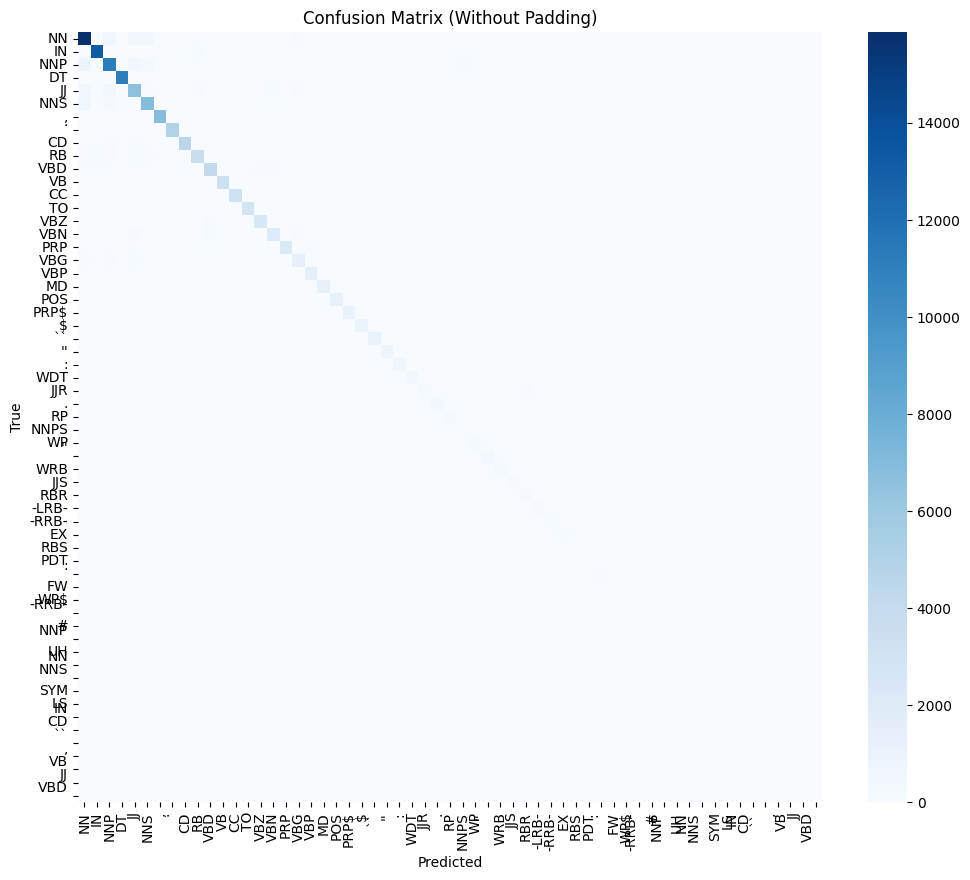

In [26]:
model_evaluation(lstm_bidirecional_model, X_test, Y_test, tag_lookup, "LSTM Bidirecional")